# Multi‑Class Hate Speech & Offensive Language Detection


## 1. Setup

In [40]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import random
import seaborn as sns   

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [41]:
# Check CUDA availability and PyTorch installation
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available")

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU name: NVIDIA GeForce RTX 3060


## 2. Data Loading & Preprocessing
- Read CSVs
- Basic tokenization (split on whitespace)
- Build vocab and load GloVe embeddings
- Create Dataset & DataLoader

In [42]:
# Paths
TRAIN_PATH = '../../data/processed/train.csv'
VAL_PATH   = '../../data/processed/val.csv'
TEST_PATH  = '../../data/processed/test.csv'

# This path needs to be updated to your local GloVe file path
GLOVE_PATH = r'C:\Users\jerry\Downloads\glove.twitter.27B\glove.twitter.27B.200d.txt'

df_train = pd.read_csv(TRAIN_PATH)
df_val   = pd.read_csv(VAL_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f"Train size: {len(df_train)}")
print(f"Val size: {len(df_val)}")
print(f"Test size: {len(df_test)}")
print(f"Label distribution in training:")
print(df_train['label'].value_counts())

def tokenize(text):
    return str(text).lower().split()

# Build vocabulary from training text
all_tokens = []
for txt in df_train['text']:
    all_tokens.extend(tokenize(txt))

vocab = {tok: i+2 for i, tok in enumerate(set(all_tokens))}
vocab['<pad>'] = 0
vocab['<unk>'] = 1
vocab_size = len(vocab)
print("Vocab size:", vocab_size)

# Load GloVe Twitter 200d embeddings
glove_dim = 200
glove_embeddings = {}
with open(GLOVE_PATH, encoding='utf8') as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vec = np.array(parts[1:], dtype=np.float32)
        if len(vec) == glove_dim:
            glove_embeddings[word] = vec

print(f"Loaded {len(glove_embeddings)} GloVe vectors.")

# Prepare embedding matrix
embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, glove_dim))
for word, idx in vocab.items():
    if word in glove_embeddings:
        embedding_matrix[idx] = glove_embeddings[word]

# Dataset class
class TextDataset(Dataset):
    def __init__(self, df, vocab, max_len=100):
        self.texts = df['text'].tolist()
        self.labels = df['label_id'].tolist()
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def encode(self, text):
        tokens = tokenize(text)
        idxs = [self.vocab.get(t, self.vocab['<unk>']) for t in tokens]
        if len(idxs) < self.max_len:
            idxs += [self.vocab['<pad>']] * (self.max_len - len(idxs))
        else:
            idxs = idxs[:self.max_len]
        return idxs

    def __getitem__(self, i):
        idxs = torch.LongTensor(self.encode(self.texts[i]))
        label = torch.LongTensor([self.labels[i]]).squeeze()
        return idxs, label

# DataLoaders
batch_size = 64
train_ds = TextDataset(df_train, vocab)
val_ds   = TextDataset(df_val, vocab)
test_ds  = TextDataset(df_test, vocab)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)

Train size: 15383
Val size: 1922
Test size: 1924
Label distribution in training:
label
normal        6251
hatespeech    4748
offensive     4384
Name: count, dtype: int64
Vocab size: 24993
Loaded 1193514 GloVe vectors.


## 3. Model Architecture: TextCNN

In [43]:
class TextCNN(nn.Module):
    def __init__(self, embedding_matrix, n_filters=32, output_dim=3, dropout=0.8):
        super().__init__()
        num_embeddings, emb_dim = embedding_matrix.shape
        
        # Embedding layer
        self.embedding = nn.Embedding(num_embeddings, emb_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = True 
        
        # Convolutional layers 
        self.conv1 = nn.Conv1d(emb_dim, n_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(emb_dim, n_filters, kernel_size=4, padding=1)
        
        # Batch normalization
        self.bn1 = nn.BatchNorm1d(n_filters)
        self.bn2 = nn.BatchNorm1d(n_filters)
        
        # Activation and pooling
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)  # Global max pooling
        
        # Classifier
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * 2, output_dim) 

    def forward(self, text):
        # Embedding
        embedded = self.embedding(text)  # [bs, seq_len, emb_dim]
        embedded = embedded.permute(0, 2, 1)  # [bs, emb_dim, seq_len]
        
        # Convolutional blocks
        conv1 = self.relu(self.bn1(self.conv1(embedded)))
        conv2 = self.relu(self.bn2(self.conv2(embedded)))
        
        # Pooling
        pooled1 = self.pool(conv1).squeeze(2)  # [bs, n_filters]
        pooled2 = self.pool(conv2).squeeze(2)
        
        # Concatenate features
        concatenated = torch.cat((pooled1, pooled2), dim=1)
        
        # Classification
        concatenated = self.dropout(concatenated)
        return self.fc(concatenated)

# Instantiate 
model = TextCNN(embedding_matrix, 
                n_filters=32,
                dropout=0.8).to(device)

## 4. Training Loop
- CrossEntropyLoss
- Adam optimizer
- Track train/val loss & accuracy

In [44]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Handle class imbalance
labels = df_train['label_id'].values
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
num_epochs = 20
patience = 3
best_val_loss = float('inf')
wait = 0
best_model_state = None

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1, num_epochs+1):
    # Training
    model.train()
    total_loss, total_correct, total_count = 0, 0, 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)
        total_loss += loss.item() * texts.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += texts.size(0)

    train_loss = total_loss / total_count
    train_acc  = total_correct / total_count

    # Validation
    model.eval()
    val_loss, val_correct, val_count = 0, 0, 0
    with torch.no_grad():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(1)
            val_loss += loss.item() * texts.size(0)
            val_correct += (preds == labels).sum().item()
            val_count += texts.size(0)

    val_loss = val_loss / val_count
    val_acc  = val_correct / val_count

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val_loss:.4f}")
            model.load_state_dict(best_model_state)
            break

Class weights: tensor([0.8203, 1.1696, 1.0800], device='cuda:0')
Epoch 1/20 | Train Loss: 1.3215, Train Acc: 0.3376 | Val Loss: 1.0933, Val Acc: 0.3283
Epoch 2/20 | Train Loss: 1.0706, Train Acc: 0.3980 | Val Loss: 0.9471, Val Acc: 0.6134
Epoch 3/20 | Train Loss: 0.9873, Train Acc: 0.4981 | Val Loss: 0.8952, Val Acc: 0.5916
Epoch 4/20 | Train Loss: 0.9308, Train Acc: 0.5566 | Val Loss: 0.8475, Val Acc: 0.6441
Epoch 5/20 | Train Loss: 0.8971, Train Acc: 0.5993 | Val Loss: 0.8195, Val Acc: 0.6582
Epoch 6/20 | Train Loss: 0.8623, Train Acc: 0.6287 | Val Loss: 0.8082, Val Acc: 0.6675
Epoch 7/20 | Train Loss: 0.8312, Train Acc: 0.6490 | Val Loss: 0.8054, Val Acc: 0.6613
Epoch 8/20 | Train Loss: 0.8018, Train Acc: 0.6629 | Val Loss: 0.7918, Val Acc: 0.6644
Epoch 9/20 | Train Loss: 0.7659, Train Acc: 0.6879 | Val Loss: 0.7928, Val Acc: 0.6707
Epoch 10/20 | Train Loss: 0.7244, Train Acc: 0.7075 | Val Loss: 0.8021, Val Acc: 0.6519
Epoch 11/20 | Train Loss: 0.6817, Train Acc: 0.7325 | Val Loss: 

## 5. Plot Loss & Accuracy

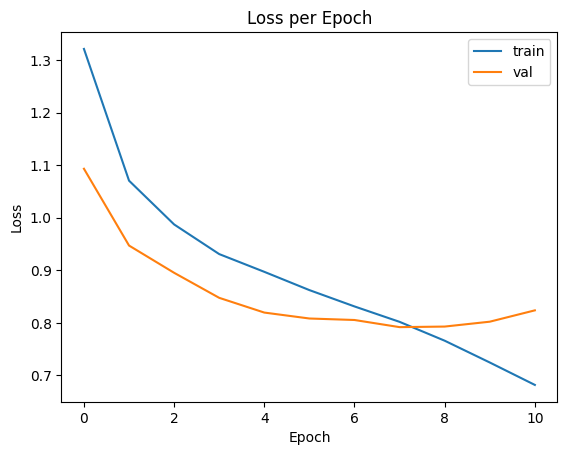

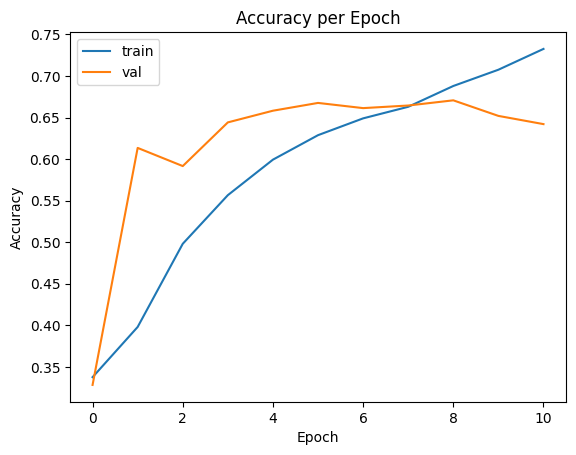

In [45]:
# Loss
plt.figure()
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'],   label='val')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(history['train_acc'], label='train')
plt.plot(history['val_acc'],   label='val')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 6. Test Set Evaluation & Confusion Matrix

Confusion Matrix:
 [[504 207  71]
 [142 295 111]
 [ 41  83 470]]


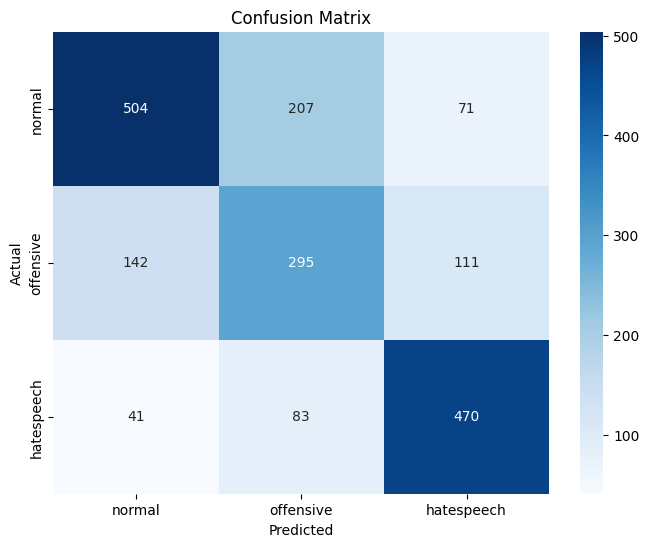


Classification Report:
               precision    recall  f1-score   support

      normal       0.73      0.64      0.69       782
   offensive       0.50      0.54      0.52       548
  hatespeech       0.72      0.79      0.75       594

    accuracy                           0.66      1924
   macro avg       0.65      0.66      0.65      1924
weighted avg       0.66      0.66      0.66      1924



In [46]:
# Gather all test preds & labels
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        outputs = model(texts)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['normal', 'offensive', 'hatespeech'],
            yticklabels=['normal', 'offensive', 'hatespeech'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Detailed report
print("\nClassification Report:\n",
      classification_report(all_labels, all_preds, target_names=['normal','offensive','hatespeech']))


## 7. Example Predictions

In [47]:
example_texts = df_test['text'].sample(5).tolist()
model.eval()
for text in example_texts:
    idxs = torch.LongTensor(TextDataset(df_test, vocab).encode(text)).unsqueeze(0).to(device)
    pred = model(idxs).argmax(1).item()
    print(f"Text: {text}\nPredicted: {['normal','offensive','hatespeech'][pred]}\n")

Text: the left applauds transgenderism it is an act of courage that must be celebrated legally endorsed and protected and woe to anyone who disagrees the left approves of transgenderism as strongly is it reproves a gay man woman wanting to transition into a heterosexual legally forbids any assistance
Predicted: normal

Text: <number> year old black man charged with raping a <number> year old child in al it no secret why the black man loves islam because that moo haamed guy tells me i gots to gets me a <number> year old maga <user> <user>
Predicted: offensive

Text: trudeau is a muzzie loving faggot he loves the goathumpers at the expense of canadians yet the canadians elected him what is wrong with canada
Predicted: hatespeech

Text: how did these jews make such an accurate representation of the pro white movement it just like us
Predicted: hatespeech

Text: <user> according to police the suspect sean bell was also in violation of driving with six suspensions yep just another day on wh